## Imports

In [1]:
# %pip install matplotlib tensorflow keras mnist scikit-learn pandas opencv-python opencv-contrib-python

In [2]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import optimizers
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import image_dataset_from_directory

# helper libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
from PIL import Image
import os

## Load data

In [3]:
# version with numpy array's for easier viewing of data
train_data = np.genfromtxt('train.csv',delimiter=',',skip_header=1, dtype='str')
train_x = train_data[:,1]
train_y = train_data[:,0]
X_train,  X_test, y_train, y_test = train_test_split(train_x,train_y,test_size=0.2)

# get image data via tf.keras.utils.image_dataset_from_directory. Folder structure is made for it. This prefents problems with only having the image name and not the pixel values
train_datatset = image_dataset_from_directory(
    "train",
    labels="inferred",
    label_mode="int",
    batch_size=50,
    validation_split=0.2,
    subset="training",
    seed=42
)

test_dataset = image_dataset_from_directory(
    "train",
    labels="inferred",
    label_mode="int",
    batch_size=50,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.


## Check labels

<table>
<tr><th>Value</th><th>Class</th></tr>
<tr><td>0</td>	<td>Black_spiny_tailed_iguana</td></tr>
<tr><td>1</td>	<td>Brown_anole</td></tr>
<tr><td>2</td>	<td>Cuban_knight_anole</td></tr>
<tr><td>3</td>	<td>Desert_iguana</td></tr>
<tr><td>4</td>	<td>Green_anole</td></tr>
<tr><td>5</td>	<td>Green_iguana</td></tr>
<tr><td>6</td>	<td>Lesser_Antillean_iguana</td></tr>
</table>


In [4]:
y_test_unique, y_test_count = np.unique(y_test,return_counts=True)
y_train_unique, y_train_count = np.unique(y_train,return_counts=True)
print(y_test_unique)
print(y_test_count)
print(y_train_unique)
print(y_train_count)

['Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_101.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_107.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_110.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_124.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_134.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_136.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_141.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_147.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_148.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_160.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_164.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_169.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_170.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_173.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_185.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_1

To check if the label distribution is random we print the first and last of test and train data.

In [5]:
# Print the first and last 10 labels from train/test set
print(y_test[:10])
print(y_test[-10:])
print(y_train[:10])
print(y_train[-10:])

['Lesser_Antillean_iguana_Lesser_Antillean_iguana_147.jpg'
 'Cuban_knight_anole_Cuban_knight_anole_171.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_160.jpg'
 'Lesser_Antillean_iguana_Lesser_Antillean_iguana_74.jpg'
 'Brown_anole_Anolis_carolinensis_19.jpg'
 'Desert_iguana_Desert_iguana_70.jpg' 'Brown_anole_Brown_anole_108.jpg'
 'Brown_anole_Brown_anole_4.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_190.jpg'
 'Lesser_Antillean_iguana_Lesser_Antillean_iguana_21.jpg']
['Desert_iguana_Desert_iguana_62.jpg'
 'Lesser_Antillean_iguana_Iguana_delicatissima_10.jpg'
 'Green_anole_Green_anole_93.jpg' 'Green_iguana_Green_iguana_49.jpg'
 'Cuban_knight_anole_Cuban_knight_anole_11.jpg'
 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_35.jpg'
 'Brown_anole_Anolis_carolinensis_10.jpg'
 'Lesser_Antillean_iguana_Lesser_Antillean_iguana_54.jpg'
 'Cuban_knight_anole_Cuban_knight_anole_149.jpg'
 'Cuban_knight_anole_Cuban_knight_anole_213.jpg']
['Green_iguana_Green_iguana_62.

Here we make a grid of the first 10 images to get an overview of what images we are working with.

In [6]:
# plt.figure(figsize=(10,10))
# for i in range(10):
#     plt.subplot(4,5,i+1)
#     plt.xticks([])
#     plt.yticks([])
#     plt.grid(False)
#     plt.imshow(X_train[i],cmap='binary')
#     plt.xlabel(class_names[y_train[i]])

## Define model settings

In [7]:
# # Define your sequential model, with the different layers, including the preprocessing layers
# model =keras.Sequential([
#     # Preprocessing: Add a Rescaling layer to rescale the pixel values to the [0, 1] range
#     layers.Rescaling(1./255),
#     # Input Layer: Add a Flattening layer to make 1-D vector of our 28x28 images
#     layers.Flatten(input_shape=(128, 128)),
#     # Hidden layer: Add a Dense layer, aka a fully or densely connected layer of 128 neurons, and let them use the 'ReLu'-squishing or activation function
#     layers.Dense(128, activation='relu'),
    
#     # Extra hidden layers
#     layers.Dense(512, activation='relu'),


#     # dropout layer applies to the layer above it 
#     # dropout disabels the selected amount(25%) of neurons during one run of the model to decrease the reliance on specific neurons
#     keras.layers.Dropout(0.25), 
#     layers.Dense(512, activation='relu'),
#     # dropout layer applies to the layer above it
#     keras.layers.Dropout(0.25),  
#     layers.Dense(256, activation='sigmoid'),
#     layers.Dense(128, activation='sigmoid'),
    
#     # Output layer: Add a Dense layer of 10 neurons (because we have 10 possible output labels), and link those neurons together in a group, via the 'softmax'-activation function
#     layers.Dense(7, activation='softmax')
# ]) 

In [8]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(256,256,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')
])

c:\Thomas_More\2APPAI\sem2\Artificial Intelligence\Groeps_werk2\De-AI-Mannen-DL\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compile model

In [9]:
# Compile the model with the adam optimizer with lr of 0.001, sparse categorical loss, and accuracy as metric
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

## Train model

In [10]:
# Train the model for 20 epochs, in batches of 50, and use a validation split of 20%.
history = model.fit(train_datatset, 
                    batch_size=50,
                    epochs = 20)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1601 - loss: 5.3820
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.2144 - loss: 1.8883
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.3006 - loss: 1.7805
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4242 - loss: 1.5787
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6386 - loss: 1.2038
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7772 - loss: 0.8336
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8605 - loss: 0.5219
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9204 - loss: 0.3117
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9429 - loss: 0.2181
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9588 - loss: 0.1729
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9644 - loss: 0.1611
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9691 - lo

## Validation

In [11]:
# def plot_training(history):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

#     ax1.plot(history.history['loss'], label='training loss')

#     if 'val_loss' in history.history:
#         ax1.plot(history.history['val_loss'], label='validation loss')

#     ax1.set_title('Loss curves')
#     ax1.set_xlabel('Epoch')
#     ax1.set_ylabel('Loss')
#     ax1.legend()

#     ax2.plot(history.history['accuracy'], label='training accuracy')

#     if 'val_accuracy' in history.history:
#         ax2.plot(history.history['val_accuracy'], label='validation accuracy')

#     ax2.set_title('Accuracy curves')
#     ax2.set_xlabel('Epoch')
#     ax2.set_ylabel('Accuracy')
#     ax2.legend()

#     fig.tight_layout()
#     plt.show()
# plot_training(history)

KeyError: 'val_loss'

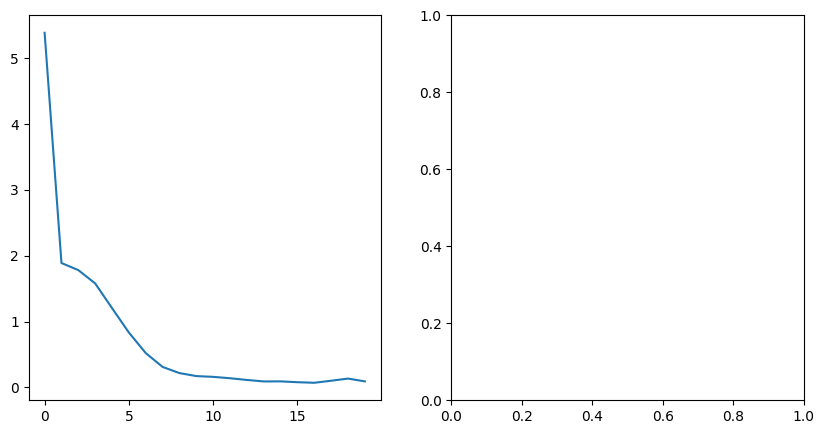

In [12]:
def plotLosses(history):
  # Create a figure and a grid of subplots with a single call
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
  # Plot the loss curves on the first subplot
  ax1.plot(history.history['loss'], label='training loss')
  ax1.plot(history.history['val_loss'], label='validation loss')
  ax1.set_title('Loss curves')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Loss')
  ax1.legend()
  # Plot the accuracy curves on the second subplot
  ax2.plot(history.history['accuracy'], label='training accuracy')
  ax2.plot(history.history['val_accuracy'], label='validation accuracy')
  ax2.set_title('Accuracy curves')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  # Adjust the spacing between subplots
  fig.tight_layout()
  # Show the figure
  plt.show()


plotLosses(history)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,531,415 (360.61 MB)

 Trainable params: 31,510,471 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,020,944 (240.41 MB)

## Prediction

In [14]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test accuracy:', test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 387ms/step - accuracy: 0.3647 - loss: 2.6228
Test accuracy: 0.36466166377067566


In [ ]:
# First, let's generate the predictions for all the test images
predictions = model.predict(train_datatset)
# Next, we'll transform all the prediction into the winners (otherwise each prediction gives us the 10 probabilities, but we only need the winner, the one our network thinks it is)
pred = np.argmax(predictions, axis=1)


In [ ]:
df = pd.DataFrame(data={"TARGET": pred.flatten()})
df.index.name = "ID" 
df.to_csv("submission.csv", index=True)